In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('proact_preprocessed_S1.csv')
df.head()

,subject_id,ALSFRS_Delta,Q1_Speech,Q2_Salivation,Q3_Swallowing,Q4_Handwriting,Q5_Cutting,Q6_Dressing_and_Hygiene,Q7_Turning_in_Bed,Q8_Walking,Q9_Climbing_Stairs,R_1_Dyspnea,R_2_Orthopnea,R_3_Respiratory_Insufficiency,Age_Base,Sex_Female,Treatment_Active,Bulbar_Onset,FVC_Base,BMI_Base
0,16497,0.0,4.0,4.0,4.0,3.0,3.0,2.0,1.0,1.0,0.0,4.0,4.0,4.0,0.016919,1.0,1.0,0.0,0.126976,-0.356485
1,53215,8.0,3.0,2.0,4.0,4.0,4.0,3.0,3.0,3.0,3.0,4.0,4.0,4.0,-1.013892,0.0,1.0,1.0,0.289065,-0.354520
2,53215,71.0,3.0,2.0,4.0,3.0,4.0,3.0,3.0,3.0,1.0,4.0,4.0,4.0,-1.013892,0.0,1.0,1.0,0.289065,-0.354520
3,53215,140.0,3.0,3.0,4.0,3.0,4.0,2.0,3.0,3.0,3.0,3.0,4.0,4.0,-1.013892,0.0,1.0,1.0,0.289065,-0.354520
4,53215,204.0,3.0,4.0,3.0,3.0,3.0,3.0,3.0,2.0,2.0,4.0,4.0,4.0,-1.013892,0.0,1.0,1.0,0.289065,-0.354520


In [3]:
import pandas as pd
import statsmodels.formula.api as smf

# 1. Create the new domain scores by summing the respective columns
df['Bulbar'] = df['Q1_Speech'] + df['Q2_Salivation'] + df['Q3_Swallowing']
df['Fine_Motor'] = df['Q4_Handwriting'] + df['Q5_Cutting'] + df['Q6_Dressing_and_Hygiene']
df['Gross_Motor'] = df['Q7_Turning_in_Bed'] + df['Q8_Walking'] + df['Q9_Climbing_Stairs']
df['Respiratory'] = df['R_1_Dyspnea'] + df['R_2_Orthopnea'] + df['R_3_Respiratory_Insufficiency']

# Define our new targets
domain_dimensions = ['Bulbar', 'Fine_Motor', 'Gross_Motor', 'Respiratory']

# Define covariates (same as before)
covariates = 'ALSFRS_Delta + Sex_Female + Treatment_Active + Age_Base + Bulbar_Onset + FVC_Base + BMI_Base'

# Dictionary to store results
domain_results = {}

# 2. Fit the models
print("Fitting LMMs for Clinical Domains...")
for domain in domain_dimensions:
    formula = f"{domain} ~ {covariates}"
    try:
        model = smf.mixedlm(formula, data=df, groups=df["subject_id"])
        result = model.fit()
        domain_results[domain] = result
        print(f"  ✓ Successfully fitted model for: {domain}")
    except Exception as e:
        print(f"  ✗ Failed to fit model for {domain}. Error: {e}")

Fitting LMMs for Clinical Domains...
  ✓ Successfully fitted model for: Bulbar
  ✓ Successfully fitted model for: Fine_Motor
  ✓ Successfully fitted model for: Gross_Motor
  ✓ Successfully fitted model for: Respiratory


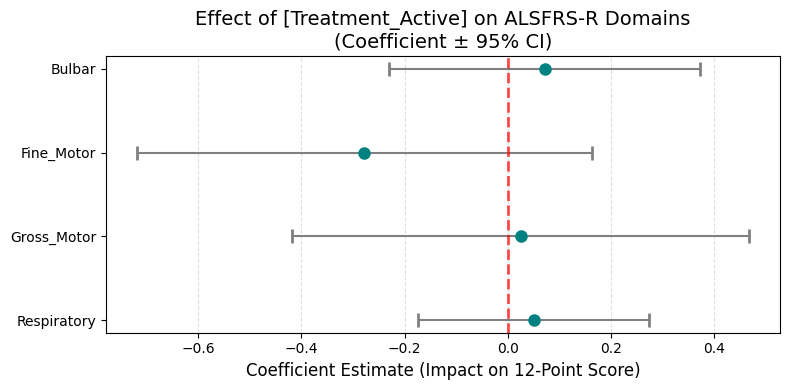

/tmp/ipykernel_1724765/4192614340.py:58: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_matrix = p_val_data.applymap(lambda p: '**' if p < 0.01 else ('*' if p < 0.05 else ''))


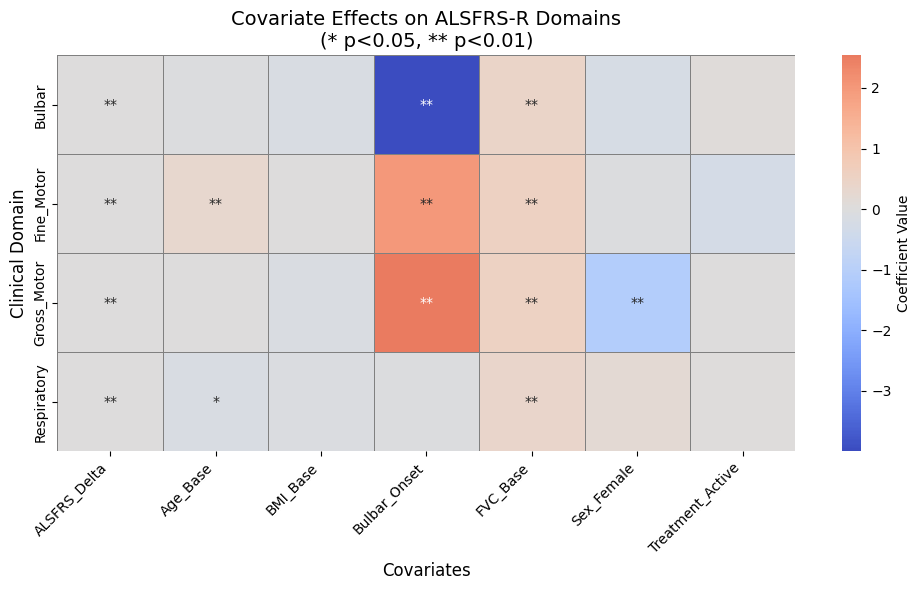

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Extract data into a DataFrame
data = []
for dim, res in domain_results.items():
    conf_int = res.conf_int()
    for covariate in res.params.index:
        if covariate == 'Intercept' or 'Group Var' in covariate:
            continue
        coef = res.params[covariate]
        p_val = res.pvalues[covariate]
        
        data.append({
            'Domain': dim,
            'Covariate': covariate,
            'Coefficient': coef,
            'CI_Lower': conf_int.loc[covariate, 0],
            'CI_Upper': conf_int.loc[covariate, 1],
            'p_value': p_val,
            'Significant': '*' if p_val < 0.05 else ''
        })

domain_results_df = pd.DataFrame(data)

# --- A. FOREST PLOT ---
def plot_domain_forest(df, target_covariate):
    cov_df = df[df['Covariate'] == target_covariate].copy()
    cov_df['err_low'] = cov_df['Coefficient'] - cov_df['CI_Lower']
    cov_df['err_upp'] = cov_df['CI_Upper'] - cov_df['Coefficient']
    
    plt.figure(figsize=(8, 4))
    plt.errorbar(x=cov_df['Coefficient'], y=cov_df['Domain'], 
                 xerr=[cov_df['err_low'], cov_df['err_upp']], 
                 fmt='o', color='teal', ecolor='gray', 
                 capsize=5, capthick=2, markersize=8)
    
    plt.axvline(x=0, color='red', linestyle='--', alpha=0.7, linewidth=2)
    plt.title(f'Effect of [{target_covariate}] on ALSFRS-R Domains\n(Coefficient ± 95% CI)', fontsize=14)
    plt.xlabel('Coefficient Estimate (Impact on 12-Point Score)', fontsize=12)
    plt.gca().invert_yaxis() 
    plt.grid(axis='x', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

# Example: Plot Treatment effect
plot_domain_forest(domain_results_df, 'Treatment_Active')

# --- B. HEATMAP ---
heatmap_data = domain_results_df.pivot(index='Domain', columns='Covariate', values='Coefficient')
p_val_data = domain_results_df.pivot(index='Domain', columns='Covariate', values='p_value')

# Reorder domains logically
heatmap_data = heatmap_data.reindex(domain_dimensions)
p_val_data = p_val_data.reindex(domain_dimensions)

annot_matrix = p_val_data.applymap(lambda p: '**' if p < 0.01 else ('*' if p < 0.05 else ''))

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, cmap='coolwarm', center=0, annot=annot_matrix, 
            fmt='', cbar_kws={'label': 'Coefficient Value'},
            linewidths=0.5, linecolor='gray')

plt.title('Covariate Effects on ALSFRS-R Domains\n(* p<0.05, ** p<0.01)', fontsize=14)
plt.xlabel('Covariates', fontsize=12)
plt.ylabel('Clinical Domain', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

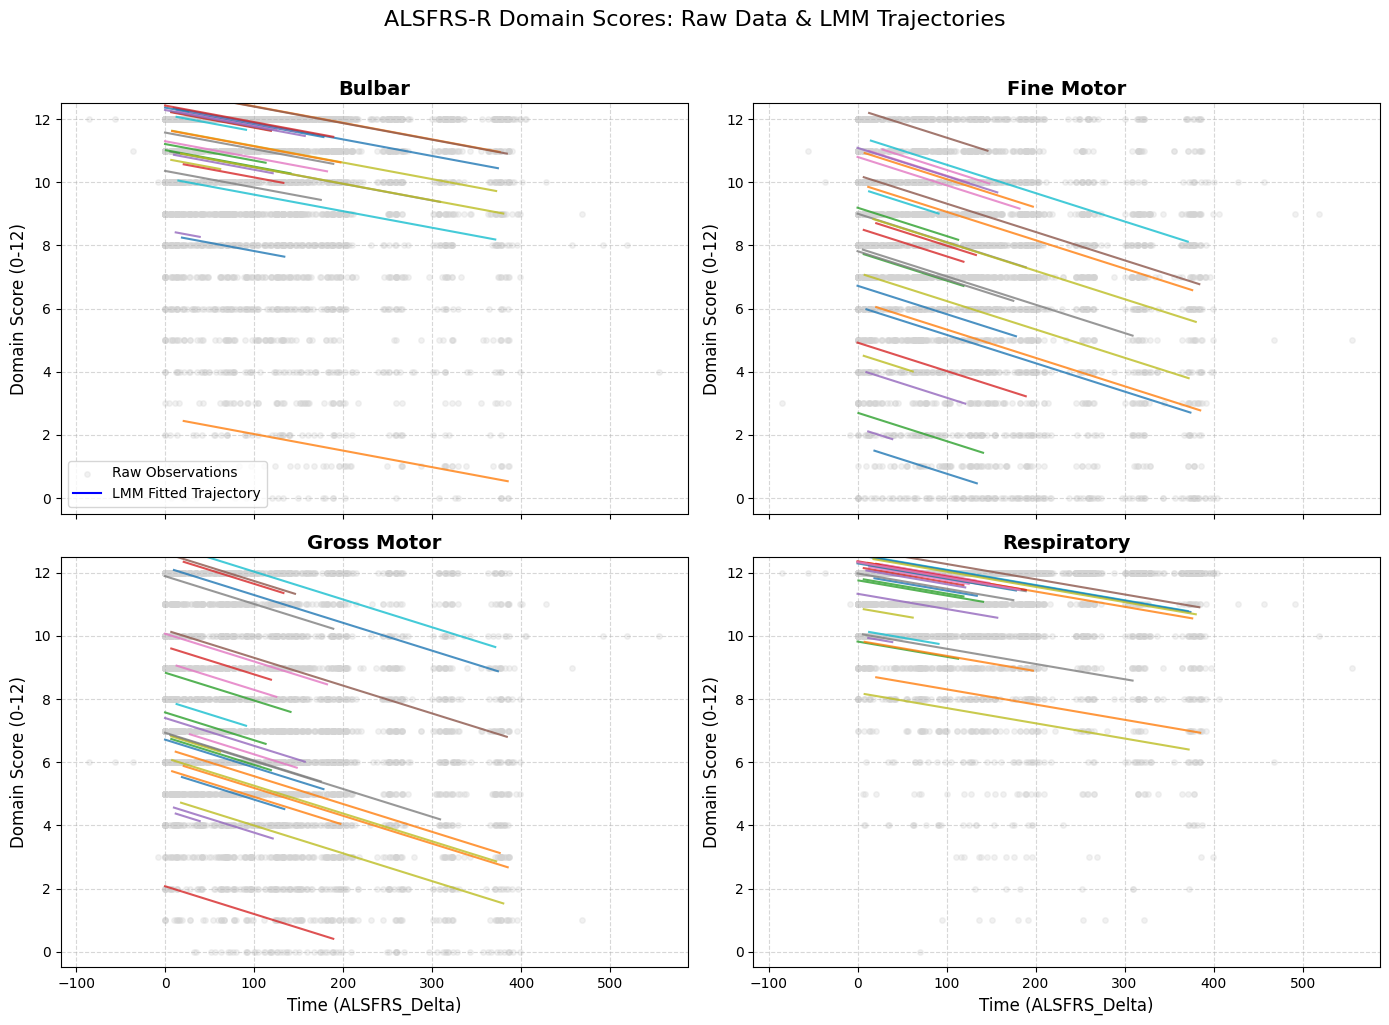

In [5]:
# Set up a 2x2 grid for the 4 domains
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
axes = axes.flatten()

# Sample 30 subjects randomly
np.random.seed(42)
all_subjects = df['subject_id'].unique()
sample_subjects = np.random.choice(all_subjects, size=30, replace=False)

for i, dim in enumerate(domain_dimensions):
    ax = axes[i]
    
    if dim not in domain_results:
        ax.set_title(f"{dim} (Model Failed)")
        continue
        
    res = domain_results[dim]
    
    # Raw Data Scatter
    ax.scatter(df['ALSFRS_Delta'], df[dim], color='lightgray', alpha=0.3, s=15, label='Raw Observations')
    
    # Extract fitted values
    df_plot = df[['subject_id', 'ALSFRS_Delta', dim]].copy()
    df_plot['fitted'] = res.fittedvalues
    
    # Filter for sampled subjects
    subset = df_plot[df_plot['subject_id'].isin(sample_subjects)]
    
    # Plot LMM Lines
    for subject in sample_subjects:
        subj_data = subset[subset['subject_id'] == subject].sort_values('ALSFRS_Delta')
        if not subj_data.empty:
            ax.plot(subj_data['ALSFRS_Delta'], subj_data['fitted'], alpha=0.8, linewidth=1.5)
    
    ax.set_title(dim.replace('_', ' '), fontsize=14, fontweight='bold')
    ax.set_ylabel('Domain Score (0-12)', fontsize=12)
    if i >= 2: # Add x-labels to the bottom row
        ax.set_xlabel('Time (ALSFRS_Delta)', fontsize=12)
        
    # Set y-limits for 12-point scale domains
    ax.set_ylim(-0.5, 12.5) 
    ax.grid(True, linestyle='--', alpha=0.5)

# Add legend
axes[0].plot([], [], color='blue', label='LMM Fitted Trajectory')
axes[0].legend(loc='lower left', fontsize=10)

plt.suptitle('ALSFRS-R Domain Scores: Raw Data & LMM Trajectories', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [6]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error

# Define the three scenarios
scenarios = {
    "2. Clinical Domains (Scale 0-12)": [
        'Bulbar', 'Fine_Motor', 'Gross_Motor', 'Respiratory'
    ]
}

covariates = 'ALSFRS_Delta + Sex_Female + Treatment_Active + Age_Base + Bulbar_Onset + FVC_Base + BMI_Base'

def evaluate_models(df, scenarios, covariates):
    results_list = []
    
    # Initialize GroupKFold to ensure patients aren't split across train/test sets
    gkf = GroupKFold(n_splits=5)
    
    for scenario_name, targets in scenarios.items():
        print(f"\nEvaluating: {scenario_name}...")
        
        for target in targets:
            formula = f"{target} ~ {covariates}"
            
            # 1. Fit the full model to get AIC / BIC
            try:
                full_model = smf.mixedlm(formula, data=df, groups=df["subject_id"]).fit(reml=False, disp=False)
                aic = full_model.aic
                bic = full_model.bic
            except Exception:
                aic, bic = np.nan, np.nan
            
            # 2. Perform 5-Fold Grouped Cross-Validation for Out-of-Sample RMSE
            fold_rmses = []
            
            for train_idx, test_idx in gkf.split(df, groups=df['subject_id']):
                train_df, test_df = df.iloc[train_idx], df.iloc[test_idx]
                
                try:
                    # Fit on training fold
                    cv_model = smf.mixedlm(formula, data=train_df, groups=train_df["subject_id"]).fit(reml=False, disp=False)
                    
                    # Predict on unseen testing fold (using fixed effects only, as random effects are unknown for new patients)
                    predictions = cv_model.predict(exog=test_df)
                    
                    # Calculate RMSE for this fold
                    rmse = np.sqrt(mean_squared_error(test_df[target], predictions))
                    fold_rmses.append(rmse)
                    
                except Exception:
                    continue # Skip if convergence fails on a specific fold
            
            # Average out-of-sample RMSE across all 5 folds
            mean_oos_rmse = np.mean(fold_rmses) if fold_rmses else np.nan
            
            results_list.append({
                'Scenario': scenario_name.split('.')[1].strip(),
                'Target': target,
                'Out-of-Sample RMSE': mean_oos_rmse,
                'AIC': aic,
                'BIC': bic
            })

    return pd.DataFrame(results_list)

# Run the evaluation (Assuming 'df' contains all previously calculated columns)
evaluation_df = evaluate_models(df, scenarios, covariates)

# Display the formatted table
print("\n" + "="*80)
print("MODEL EVALUATION: OUT-OF-SAMPLE RMSE AND INFORMATION CRITERIA")
print("="*80)
# Format columns for cleaner reading
format_dict = {
    'Out-of-Sample RMSE': '{:.3f}'.format, 
    'AIC': '{:.1f}'.format, 
    'BIC': '{:.1f}'.format
}
print(evaluation_df.to_string(formatters=format_dict, index=False))


Evaluating: 2. Clinical Domains (Scale 0-12)...

MODEL EVALUATION: OUT-OF-SAMPLE RMSE AND INFORMATION CRITERIA
                     Scenario      Target Out-of-Sample RMSE     AIC     BIC
Clinical Domains (Scale 0-12)      Bulbar              2.070 14223.7 14287.4
Clinical Domains (Scale 0-12)  Fine_Motor              2.909 15708.4 15772.1
Clinical Domains (Scale 0-12) Gross_Motor              2.908 15653.6 15717.3
Clinical Domains (Scale 0-12) Respiratory              1.711 14720.0 14783.7


In [7]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from sklearn.metrics import mean_squared_error
from girth import grm_mml
from scipy.special import expit
from factor_analyzer import FactorAnalyzer
import warnings

warnings.filterwarnings("ignore")

# ==========================================
# 0. SETUP AND HELPER FUNCTIONS
# ==========================================
# IMPORTANT: Ensure your longitudinal dataframe is loaded as 'df'

domains = {
    'Bulbar': ['Q1_Speech', 'Q2_Salivation', 'Q3_Swallowing'],
    'Fine_Motor': ['Q4_Handwriting', 'Q5_Cutting', 'Q6_Dressing_and_Hygiene'],
    'Gross_Motor': ['Q7_Turning_in_Bed', 'Q8_Walking', 'Q9_Climbing_Stairs'],
    'Respiratory': ['R_1_Dyspnea', 'R_2_Orthopnea', 'R_3_Respiratory_Insufficiency']
}
all_items = [item for sublist in domains.values() for item in sublist]
scenarios = {**domains}

# Covariates (Ensure these match your actual dataframe columns)
covariates = 'ALSFRS_Delta + Sex_Female + Treatment_Active + Age_Base'
covariates_ar = 'Time_Since_Last_Visit + Sex_Female + Treatment_Active + Age_Base'

results_list = []

def get_expected_item_score(theta, discrimination, thresholds):
    """Maps latent theta back to expected 0-4 item score."""
    p_ge_1 = expit(discrimination * (theta - thresholds[0]))
    p_ge_2 = expit(discrimination * (theta - thresholds[1]))
    p_ge_3 = expit(discrimination * (theta - thresholds[2]))
    p_ge_4 = expit(discrimination * (theta - thresholds[3]))
    
    p4 = p_ge_4
    p3 = p_ge_3 - p_ge_4
    p2 = p_ge_2 - p_ge_3
    p1 = p_ge_1 - p_ge_2
    p0 = 1.0 - p_ge_1
    return (0 * p0) + (1 * p1) + (2 * p2) + (3 * p3) + (4 * p4)

# ==========================================
# BASELINE 1: NAIVE LMM (RAW SCORES)
# ==========================================
print("1. Fitting Naive LMM (In-Sample)...")

# Create aggregate targets
for dom, items in domains.items():
    df[dom] = df[items].sum(axis=1)

targets_naive = {
    'Domain': list(domains.keys()), 
}

for level, t_list in targets_naive.items():
    for target in t_list:
        formula = f"Q('{target}') ~ {covariates}" if ' ' in target else f"{target} ~ {covariates}"
        try:
            model = smf.mixedlm(formula, data=df, groups=df["subject_id"]).fit(reml=False, disp=False)
            rmse = np.sqrt(mean_squared_error(df[target], model.fittedvalues))
            results_list.append({'Model': '1. Naive LMM', 'Level': level, 'Target': target, 'In-Sample RMSE': rmse})
        except Exception as e:
            pass




# ==========================================
# 4. FORMAT FINAL COMPARISON TABLE
# ==========================================
eval_df = pd.DataFrame(results_list)

# Set logical order for the table
eval_df['Level'] = pd.Categorical(eval_df['Level'], categories=['Overall', 'Domain', 'Individual Item'], ordered=True)
eval_df = eval_df.sort_values(['Level', 'Target', 'Model'])

# Pivot the table so Models are columns, and Targets are rows
pivot_df = eval_df.pivot(index=['Level', 'Target'], columns='Model', values='In-Sample RMSE')

print("\n" + "="*85)
print("IN-SAMPLE RMSE ABLATION STUDY: BASELINE MODELS")
print("="*85)
print(pivot_df.to_string(float_format="{:.3f}".format))

1. Fitting Naive LMM (In-Sample)...

IN-SAMPLE RMSE ABLATION STUDY: BASELINE MODELS
Model               1. Naive LMM
Level  Target                   
Domain Bulbar              0.876
       Fine_Motor          0.994
       Gross_Motor         0.985
       Respiratory         1.011


In [8]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from sklearn.metrics import mean_squared_error, mean_absolute_error, cohen_kappa_score
from girth import grm_mml
from scipy.special import expit
from factor_analyzer import FactorAnalyzer
import warnings

warnings.filterwarnings("ignore")

# ==========================================
# 0. SETUP & DATA PREP
# ==========================================
print("Loading data and setting up...")
# IMPORTANT: Load your actual patient data here
df = pd.read_csv('proact_preprocessed_S1.csv') 

domains = {
    'Bulbar': ['Q1_Speech', 'Q2_Salivation', 'Q3_Swallowing'],
    'Fine_Motor': ['Q4_Handwriting', 'Q5_Cutting', 'Q6_Dressing_and_Hygiene'],
    'Gross_Motor': ['Q7_Turning_in_Bed', 'Q8_Walking', 'Q9_Climbing_Stairs'],
    'Respiratory': ['R_1_Dyspnea', 'R_2_Orthopnea', 'R_3_Respiratory_Insufficiency']
}
all_items = [item for sublist in domains.values() for item in sublist]
scenarios = {'Total Score': all_items, **domains}

# Add aggregated true scores to dataframe
df['Total Score'] = df[all_items].sum(axis=1)
for dom, items in domains.items():
    df[dom] = df[items].sum(axis=1)

covariates = 'ALSFRS_Delta + Sex_Female + Treatment_Active + Age_Base'
covariates_ar = 'Time_Since_Last_Visit + Sex_Female + Treatment_Active + Age_Base'

results_list = []

def record_metrics(model_name, level, target, actual, expected, is_item=False):
    """Helper function to calculate and store all advanced metrics."""
    rmse = np.sqrt(mean_squared_error(actual, expected))
    mae = mean_absolute_error(actual, expected)
    
    if is_item:
        pred_cat = np.clip(np.round(expected), 0, 4)
        exact = np.mean(pred_cat == actual) * 100
        kappa = cohen_kappa_score(actual, pred_cat, weights='linear')
    else:
        exact, kappa = np.nan, np.nan
        
    results_list.append({
        'Model': model_name, 'Level': level, 'Target': target,
        'RMSE': rmse, 'MAE': mae, 'Exact Match %': exact, 'Weighted Kappa': kappa
    })

def get_irt_expected(theta, discrimination, thresholds):
    """Maps latent theta back to 0-4 scale."""
    p_ge = [expit(discrimination * (theta - th)) for th in thresholds]
    p4 = p_ge[3]
    p3 = p_ge[2] - p_ge[3]
    p2 = p_ge[1] - p_ge[2]
    p1 = p_ge[0] - p_ge[1]
    p0 = 1.0 - p_ge[0]
    return (0 * p0) + (1 * p1) + (2 * p2) + (3 * p3) + (4 * p4)

# ==========================================
# 1. BASELINE 1: NAIVE LMM
# ==========================================
print("Fitting 1. Naive LMM...")
targets_naive = {'Domain': list(domains.keys())}

for level, t_list in targets_naive.items():
    for target in t_list:
        formula = f"Q('{target}') ~ {covariates}" if ' ' in target else f"{target} ~ {covariates}"
        try:
            model = smf.mixedlm(formula, data=df, groups=df["subject_id"]).fit(reml=False, disp=False)
            expected = model.fittedvalues
            # Enforce clinical boundaries for Naive LMM metrics
            max_val = 48 if level == 'Overall' else (12 if level == 'Domain' else 4)
            expected = np.clip(expected, 0, max_val)
            record_metrics('1. Naive LMM', level, target, df[target], expected, is_item=(level=='Individual Item'))
        except: pass

# # ==========================================
# # 2. BASELINE 2: IRT + LATENT LMM
# # ==========================================
# print("Fitting 2. IRT + Latent LMM...")
# for target_name, items in scenarios.items():
#     level = 'Overall' if target_name == 'Total Score' else 'Domain'
#     irt_data = df[items].astype(int).values.T + 1
#     irt_results = grm_mml(irt_data)
#     df['theta'] = irt_results['Ability']
    
#     try:
#         model = smf.mixedlm(f"theta ~ {covariates}", data=df, groups=df["subject_id"]).fit(reml=False, disp=False)
#         expected_agg = np.zeros(len(df))
        
#         for i, item in enumerate(items):
#             exp_item = get_irt_expected(model.fittedvalues, irt_results['Discrimination'][i], irt_results['Difficulty'][i])
#             expected_agg += exp_item
#             if level == 'Domain': # Capture items during domain loops
#                 record_metrics('2. IRT + LMM', 'Individual Item', item, df[item], exp_item, is_item=True)
                
#         record_metrics('2. IRT + LMM', level, target_name, df[target_name], expected_agg, is_item=False)
#     except: pass

# # ==========================================
# # 3. BASELINE 3: DISCRETE-TIME FA
# # ==========================================
# print("Fitting 3. Discrete-Time FA...")
# df = df.sort_values(by=['subject_id', 'ALSFRS_Delta'])
# df['Delta_Lag'] = df.groupby('subject_id')['ALSFRS_Delta'].shift(1)
# df['Time_Since_Last_Visit'] = df['ALSFRS_Delta'] - df['Delta_Lag']

# for target_name, items in scenarios.items():
#     level = 'Overall' if target_name == 'Total Score' else 'Domain'
#     fa = FactorAnalyzer(n_factors=1, rotation=None)
#     fa.fit(df[items])
#     df['Factor'] = fa.transform(df[items])[:, 0]
    
#     df['Factor_Lag'] = df.groupby('subject_id')['Factor'].shift(1)
#     df_dyn = df.dropna(subset=['Factor_Lag', 'Time_Since_Last_Visit']).copy()
#     formula = f"Factor ~ Factor_Lag + {covariates_ar}"
    
#     try: # LMM with OLS Fallback
#         try:
#             model = smf.mixedlm(formula, data=df_dyn, groups=df_dyn["subject_id"])
#             fitted_factor = model.fit(method='lbfgs', reml=False, disp=False).fittedvalues
#         except:
#             fitted_factor = smf.ols(formula, data=df_dyn).fit().fittedvalues
            
#         expected_agg = np.zeros(len(df_dyn))
#         for i, item in enumerate(items):
#             exp_item = np.clip((fitted_factor * fa.loadings_[:, 0][i]) + df_dyn[items].mean().values[i], 0, 4)
#             expected_agg += exp_item
#             if level == 'Domain':
#                 record_metrics('3. Discrete FA', 'Individual Item', item, df_dyn[item], exp_item, is_item=True)
                
#         record_metrics('3. Discrete FA', level, target_name, df_dyn[target_name], expected_agg, is_item=False)
#     except: pass

# ==========================================
# 4. FORMAT AND PRINT OUTPUT
# ==========================================
eval_df = pd.DataFrame(results_list)
eval_df['Level'] = pd.Categorical(eval_df['Level'], categories=['Overall', 'Domain', 'Individual Item'], ordered=True)

# Helper to print pivot tables
def print_metric_table(metric_name, format_str):
    pivot = eval_df.pivot(index=['Level', 'Target'], columns='Model', values=metric_name)
    print("\n" + "="*80)
    print(f"BASELINE COMPARISON: {metric_name}")
    print("="*80)
    print(pivot.to_string(float_format=lambda x: format_str.format(x) if pd.notnull(x) else "-"))

print_metric_table('RMSE', "{:.3f}")
print_metric_table('MAE', "{:.3f}")
print_metric_table('Exact Match %', "{:.1f}%")
print_metric_table('Weighted Kappa', "{:.3f}")

Loading data and setting up...
Fitting 1. Naive LMM...

BASELINE COMPARISON: RMSE
Model               1. Naive LMM
Level  Target                   
Domain Bulbar              0.862
       Fine_Motor          0.985
       Gross_Motor         0.975
       Respiratory         1.000

BASELINE COMPARISON: MAE
Model               1. Naive LMM
Level  Target                   
Domain Bulbar              0.564
       Fine_Motor          0.730
       Gross_Motor         0.723
       Respiratory         0.634

BASELINE COMPARISON: Exact Match %
Model               1. Naive LMM
Level  Target                   
Domain Bulbar                NaN
       Fine_Motor            NaN
       Gross_Motor           NaN
       Respiratory           NaN

BASELINE COMPARISON: Weighted Kappa
Model               1. Naive LMM
Level  Target                   
Domain Bulbar                NaN
       Fine_Motor            NaN
       Gross_Motor           NaN
       Respiratory           NaN
